In [11]:
!pip install ipympl

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ipympl]2m2/4 [ipywidgets]widgets]


In [7]:
import os

%matplotlib widget

In [8]:
import mne

In [9]:
raw = mne.io.read_raw_edf('/home/user01/aiotlab/pqhung/EEG/108CMH/FA5550A0/FA5550A0_1-1+.edf')

Extracting EDF parameters from /home/user01/aiotlab/pqhung/EEG/108CMH/FA5550A0/FA5550A0_1-1+.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


In [23]:
selected_channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

raw.pick_channels(selected_channels, ordered=True)
# print(raw.info)
raw.resample(200)
raw.filter(l_freq=0.3, h_freq=75)
raw.notch_filter((50))

import numpy as np

print(raw.info)
data_V = raw.get_data()                       # Volt
df_uV  = raw.to_data_frame()   # EEG = µV
print(np.mean(np.abs(data_V)) * 1e6, '≈ mean |µV| (từ Volt)')
print(np.mean(np.abs(df_uV.drop(columns=['time']).values)), '≈ mean |µV| (DataFrame)')

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 200.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 75 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 75.00 Hz
- Upper transition bandwidth: 18.75 Hz (-6 dB cutoff frequency: 84.38 Hz)
- Filter length: 2201 samples (11.005 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ri

Using matplotlib as 2D backend.


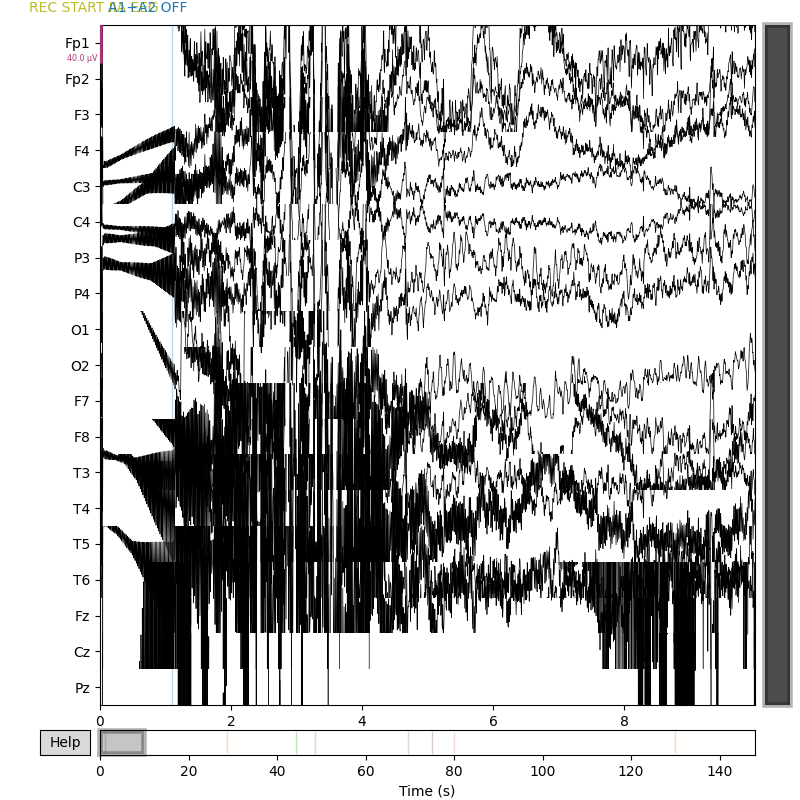

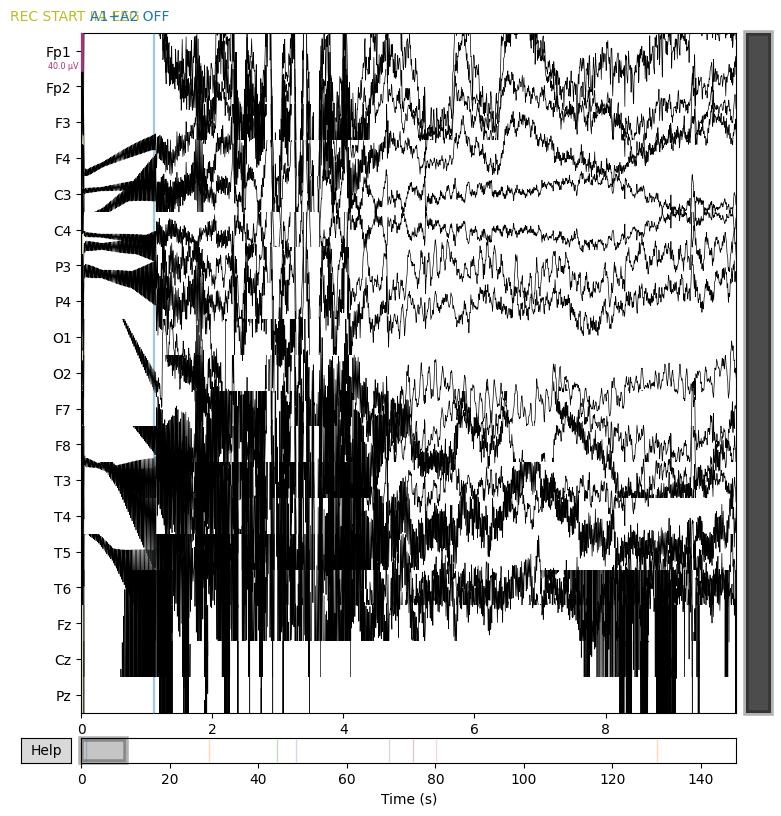

In [6]:
raw.plot()